In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tqdm
import os
from typing import Optional, List, Dict
from IPython.display import clear_output
import json

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import torch
import torch.utils.data as data
import torch.nn as nn
import wandb

sns.set_theme(context="notebook", palette="muted")

In [2]:
data2019 = pd.read_csv('../data/ISIC_2019_Training_Metadata.csv')
truth2019 = pd.read_csv('../data/ISIC_2019_Training_GroundTruth.csv')
data2020 = pd.read_csv('../data/ISIC_2020_Training_GroundTruth.csv')

### EDA

In [3]:
truth2019['target'] = truth2019['MEL'].astype('Int64')
truth2019 = truth2019.rename(columns={'image' : 'image_name'})[['image_name', 'target']]
data2020 = data2020[['image_name', 'sex', 'age_approx', 'anatom_site_general_challenge', 'target']].rename(columns={'anatom_site_general_challenge' : 'anatom_site_general'})
data2019 = pd.merge(left=data2019.rename(columns={'image' : 'image_name'}), right=truth2019, on='image_name').drop(columns='lesion_id')
data2019

,image_name,age_approx,anatom_site_general,sex,target
0,ISIC_0000000,55.0,anterior torso,female,0
1,ISIC_0000001,30.0,anterior torso,female,0
2,ISIC_0000002,60.0,upper extremity,female,1
3,ISIC_0000003,30.0,upper extremity,male,0
4,ISIC_0000004,80.0,posterior torso,male,1
...,...,...,...,...,...
25326,ISIC_0073247,85.0,head/neck,female,0
25327,ISIC_0073248,65.0,anterior torso,male,0
25328,ISIC_0073249,70.0,lower extremity,male,1
25329,ISIC_0073251,55.0,palms/soles,female,0


In [4]:
all_data = pd.concat([data2019, data2020], axis=0).reset_index(drop=True)

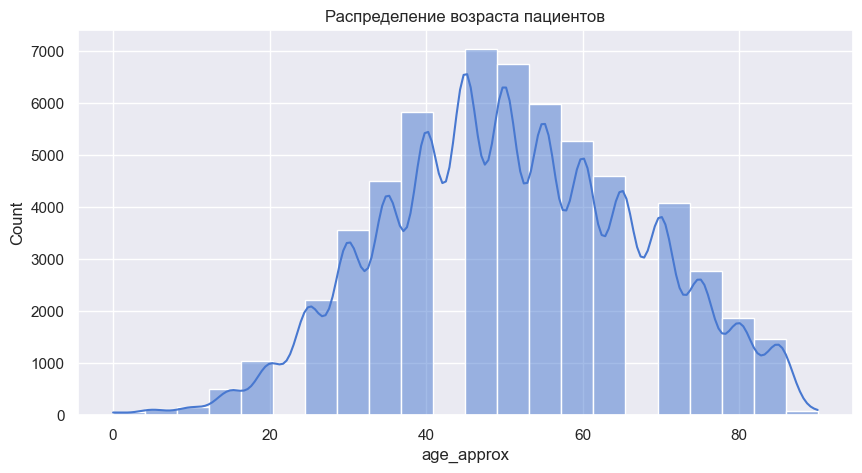

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(all_data['age_approx'], binwidth=4, kde=True)
plt.title('Распределение возраста пациентов');

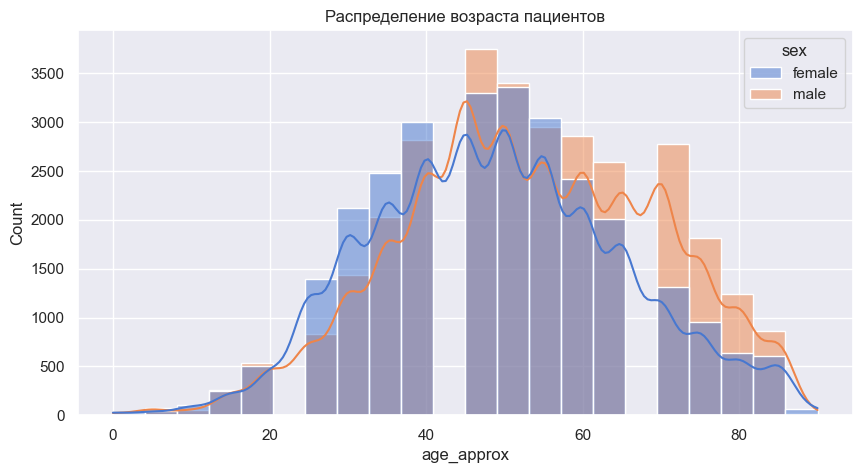

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(data=all_data, x='age_approx', hue='sex', binwidth=4, kde=True)
plt.title('Распределение возраста пациентов');

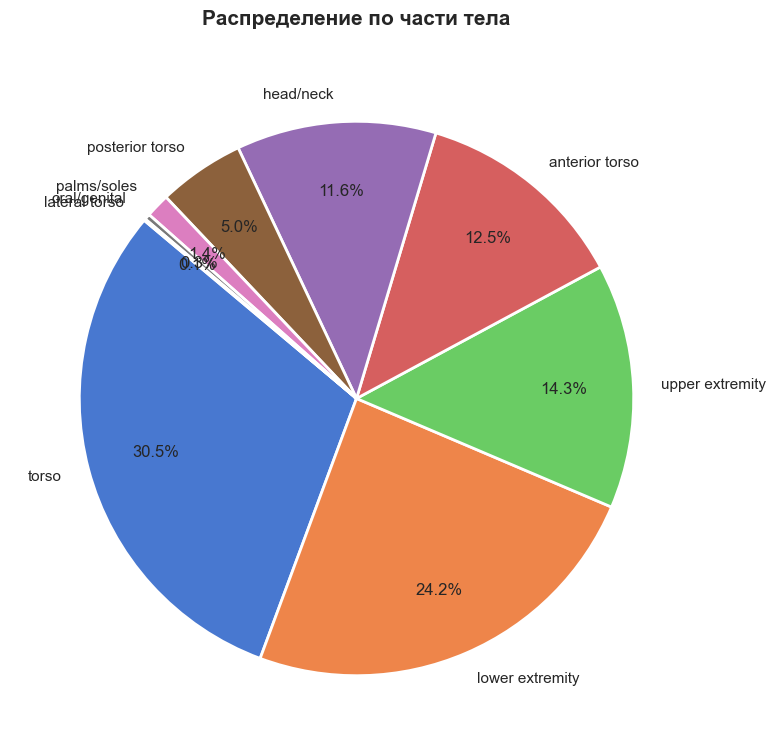

In [7]:
plt.figure(figsize=(9, 9))
plt.pie(all_data['anatom_site_general'].value_counts() / len(all_data), labels=(all_data['anatom_site_general'].value_counts() / len(all_data)).index, autopct='%1.1f%%', startangle=140, pctdistance=0.75, wedgeprops={'edgecolor' : 'white', 'linewidth' : 2})
plt.title('Распределение по части тела', fontsize=15, fontweight='bold', pad=20);

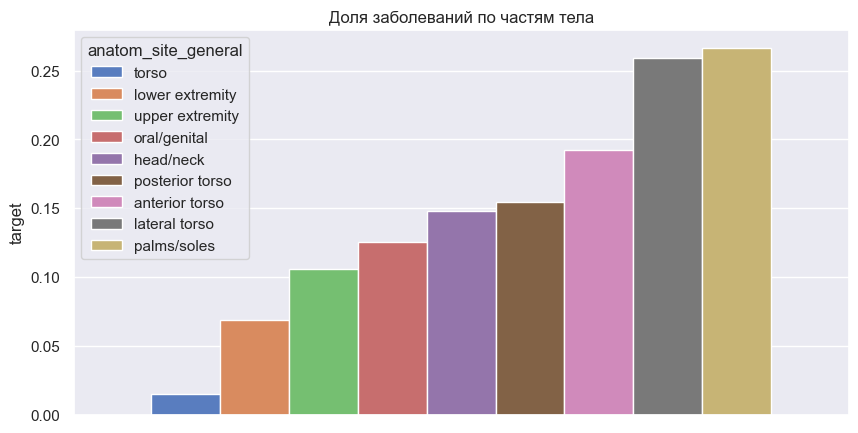

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(all_data[['anatom_site_general', 'target']].groupby('anatom_site_general', as_index=False).mean().sort_values('target'), hue='anatom_site_general', y='target')
plt.title('Доля заболеваний по частям тела');

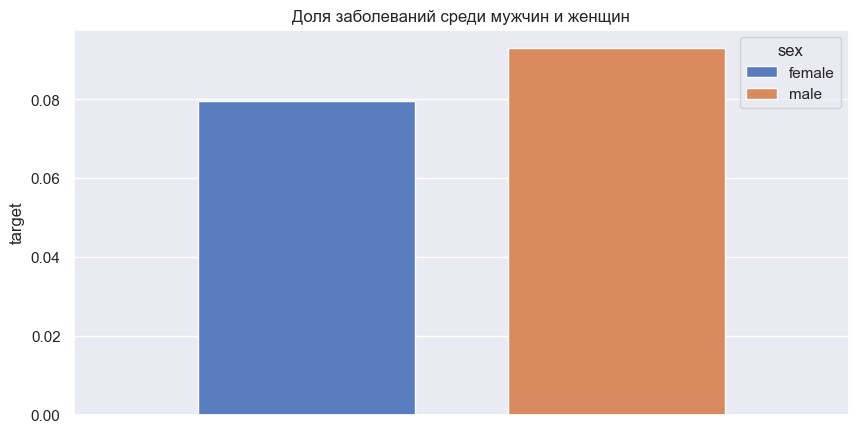

In [9]:
plt.figure(figsize=(10, 5))
sns.barplot(all_data[['sex', 'target']].groupby('sex').mean(), hue='sex', y='target', gap=0.3)
plt.title('Доля заболеваний среди мужчин и женщин');

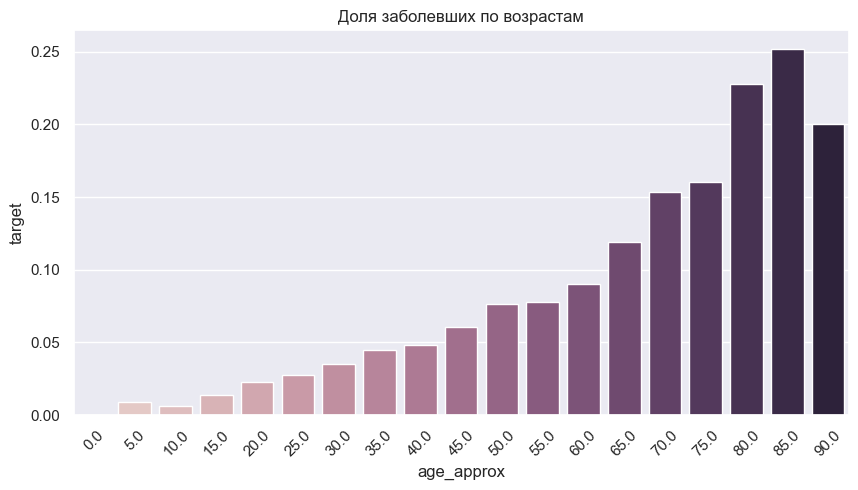

In [10]:
plt.figure(figsize=(10, 5))
sns.barplot(all_data[['age_approx', 'target']].groupby('age_approx').mean(), hue='age_approx', y='target', x='age_approx', legend=False)
plt.xticks(rotation=45)
plt.title('Доля заболевших по возрастам');

### Построение моделей

In [11]:
test_data = pd.read_csv('../data/ISIC_2019_Test_Metadata.csv')
test_target = pd.read_csv('../data/ISIC_2019_Test_GroundTruth.csv')
test_target['target'] = test_target['MEL'].astype('Int64')
test_target = test_target.rename(columns={'image' : 'image_name'})[['image_name', 'target']]
test_target['target'].mean()
test = pd.merge(left=test_data.rename(columns={'image' : 'image_name'}), right=test_target, on='image_name').dropna()

In [12]:
train_data, val_data = train_test_split(data2019.dropna(), test_size=0.1, random_state=33, stratify=data2019.dropna()['target'])

In [13]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore').set_output(transform='pandas')
train_data = pd.concat([train_data, ohe.fit_transform(train_data[['anatom_site_general']])], axis=1)
test = pd.concat([test, ohe.transform(test[['anatom_site_general']])], axis=1)
val_data = pd.concat([val_data, ohe.transform(val_data[['anatom_site_general']])], axis=1)

In [14]:
ordenc = OrdinalEncoder().set_output(transform='pandas')
train_data['sex'] = ordenc.fit_transform(train_data[['sex']])
test['sex'] = ordenc.transform(test[['sex']])
val_data['sex'] = ordenc.transform(val_data[['sex']])

In [15]:
train_data.drop(columns=['image_name', 'anatom_site_general'], inplace=True)
test.drop(columns=['image_name', 'anatom_site_general'], inplace=True)
val_data.drop(columns=['image_name', 'anatom_site_general'], inplace=True)

In [16]:
scaler = StandardScaler().set_output(transform='pandas')
train_data['age_approx'] = scaler.fit_transform(train_data[['age_approx']])
test['age_approx'] = scaler.transform(test[['age_approx']])
val_data['age_approx'] = scaler.transform(val_data[['age_approx']])

### Функции для обучения и валидации модели

In [17]:
def training_epoch(model : nn.Module, optimizer : torch.optim.Optimizer, criterion : nn.Module, train_loader : data.DataLoader, device : torch.device, tqdm_desc='Train'):
    model.train()

    loss_sum = 0.0
    n_samples = 0

    all_probs = []
    all_targets = []

    pbar = tqdm.tqdm(train_loader, desc=tqdm_desc)
    for x, y in pbar:
        x = x.to(device).float()
        y = y.to(device).float()

        optimizer.zero_grad()

        logits = model(x).squeeze(1)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        bs = x.size(0)
        loss_sum += float(loss.item()) * bs
        n_samples += bs

        all_targets.extend(y.cpu().detach().numpy().flatten().tolist())
        all_probs.extend(logits.sigmoid().cpu().detach().numpy().flatten().tolist())

        avg_loss = loss_sum / max(1, n_samples)

        pbar.set_postfix({'loss': f'{avg_loss:.4f}'})

    return {'loss' : loss_sum / max(1, n_samples), 'roc_auc' : roc_auc_score(all_targets, all_probs)}


@torch.no_grad()
def validation_epoch(model : nn.Module, criterion : nn.Module, valid_loader : data.DataLoader, device : torch.device, tqdm_desc='Valid'):
    model.eval()

    loss_sum = 0.0
    n_samples = 0

    all_probs = []
    all_targets = []

    pbar = tqdm.tqdm(valid_loader, desc=tqdm_desc)
    for x, y in pbar:
        x = x.to(device).float()
        y = y.to(device).float()

        logits = model(x).squeeze(1)
        loss = criterion(logits, y)

        bs = x.size(0)
        loss_sum += float(loss.item()) * bs
        n_samples += bs

        all_targets.extend(y.cpu().detach().numpy().flatten().tolist())
        all_probs.extend(logits.sigmoid().cpu().detach().numpy().flatten().tolist())

        avg_loss = loss_sum / max(1, n_samples)

        pbar.set_postfix({'loss': f'{avg_loss:.4f}'})
    

    return {'loss' : loss_sum / max(1, n_samples), 'roc_auc' : roc_auc_score(all_targets, all_probs)}

def plot_metrics(train_losses, val_losses, train_auc_roc, val_auc_roc):
    clear_output(True)
    epochs = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss', marker='o')
    plt.plot(epochs, val_losses, label='Val Loss', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Dynamics')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_auc_roc, label='Train AUC-ROC', marker='o')
    plt.plot(epochs, val_auc_roc, label='Val AUC-ROC', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('AUC-ROC')
    plt.title('AUC-ROC Dynamics')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.ylim([-0.05, 1.05])
    plt.legend()

    plt.tight_layout()
    plt.show()

def save_checkpoint(path: str, model: nn.Module, optimizer: torch.optim.Optimizer, epoch: int, val_loss : float) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({'epoch': epoch, 'val_loss': val_loss, 'model_state': model.state_dict(), 'optimizer_state': optimizer.state_dict()}, path)

def fit(model : nn.Module, train_loader : data.DataLoader, val_loader : data.DataLoader, optimizer : torch.optim.Optimizer, criterion : nn.Module, device : torch.device, num_epochs: int, out_dir: str = None, plot_fn=None, use_wandb: bool = False, wandb_project: str = None, wandb_run_name: Optional[str] = None, wandb_config: Optional[dict] = None, save_every_n_epochs : int = 1) -> Dict[str, List[float]]:
    model.to(device)

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_roc_auc' : [],
        'val_roc_auc' : [],
    }

    best_roc_auc = 0

    run = None
    if use_wandb:
        run = wandb.init(project=wandb_project, name=wandb_run_name, config=wandb_config if wandb_config else {})
        wandb.config.update({'num_params': sum(p.numel() for p in model.parameters()), 'device': str(device)}, allow_val_change=True)

    for epoch in range(1, num_epochs + 1):
        tr = training_epoch(model=model, train_loader=train_loader, optimizer=optimizer, criterion=criterion, device=device, tqdm_desc=f'Train {epoch}/{num_epochs}')
        va = validation_epoch(model=model, valid_loader=val_loader, criterion=criterion, device=device, tqdm_desc=f'Valid {epoch}/{num_epochs}',)

        history['train_loss'].append(tr['loss'])
        history['train_roc_auc'].append(tr['roc_auc'])
        history['val_loss'].append(va['loss'])
        history['val_roc_auc'].append(va['roc_auc'])
        
        if epoch % save_every_n_epochs == 0: save_checkpoint(os.path.join(out_dir, 'checkpoints', f"epoch_{epoch:03d}.pt"), model, optimizer, epoch, va['loss'])
        if va['roc_auc'] >= best_roc_auc: save_checkpoint(os.path.join(out_dir, 'checkpoints', 'best.pt'), model, optimizer, epoch, va['loss'])

        print(f'[{epoch:02d}/{num_epochs}] train: loss={tr["loss"]:.4f}, roc_auc={tr["roc_auc"]:.4f} | val: loss={va["loss"]:.4f}, roc_auc={va["roc_auc"]:.4f}')
        
        if plot_fn:
            plot_fn(history['train_loss'], history['val_loss'], history['train_roc_auc'], history['val_roc_auc'])

        if use_wandb:
            wandb.log({'epoch': epoch, 'train/loss': tr['loss'], 'train/roc_auc': tr['roc_auc'], 'val/loss': va['loss'], 'val/roc_auc': va['roc_auc']}, step=epoch)

        os.makedirs(f'{out_dir}/logs/', exist_ok=True)
        with open(f'{out_dir}/logs/history.json', 'w', encoding='utf-8') as f:
            json.dump(history, f, ensure_ascii=False, indent=4)

    os.makedirs(os.path.dirname(f'{out_dir}/data/'), exist_ok=True)
    torch.save(train_loader.dataset.tensors, f'{out_dir}/data/train_dataset.pt')
    torch.save(val_loader.dataset.tensors, f'{out_dir}/data/val_dataset.pt')

    if use_wandb and run is not None:
        run.finish()

    return history

### Простая модель: однослойная сеть

In [18]:
wandb_config = {
    "project": "gp5_tabular_model1",
    "run_type": "train",
    "seed": 33,

    "dataset": "dogs-vs-cats-redux",
    "split": {
        "type": "stratified",
        "val_size": 0.1,
        "random_state": 33,
    },

    "device": "mps",
    "epochs": 50,
    "batch_size": 128,

    "optimizer": {
        "name": "Adam",
        "lr": 0.0005,
        "betas": [0.9, 0.999],
        "eps": 1e-8,
    },
    "criterion": "BCEWithLogitsLoss",

    "log": {
        "log_every_epoch": True,
        "save_best": True,
        "checkpoint_dir": "model1",
    }
}

In [19]:
train_dataset = data.TensorDataset(torch.tensor(train_data.drop(columns='target').to_numpy().astype(float)), torch.tensor(train_data['target'].to_numpy().astype(float)))
val_dataset = data.TensorDataset(torch.tensor(val_data.drop(columns='target').to_numpy().astype(float)), torch.tensor(val_data['target'].to_numpy().astype(float)))
test_dataset = data.TensorDataset(torch.tensor(test.drop(columns='target').to_numpy().astype(float)), torch.tensor(test['target'].to_numpy().astype(float)))

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor((train_data['target'] == 0).sum() / (train_data['target'] == 1).sum()))

train_loader = data.DataLoader(train_dataset, 128, shuffle=True)
val_loader = data.DataLoader(val_dataset, 1024)
test_loader = data.DataLoader(test_dataset, 1024)

model = nn.Linear(10, 1)

optimizer = torch.optim.Adam(model.parameters(), 0.0005)

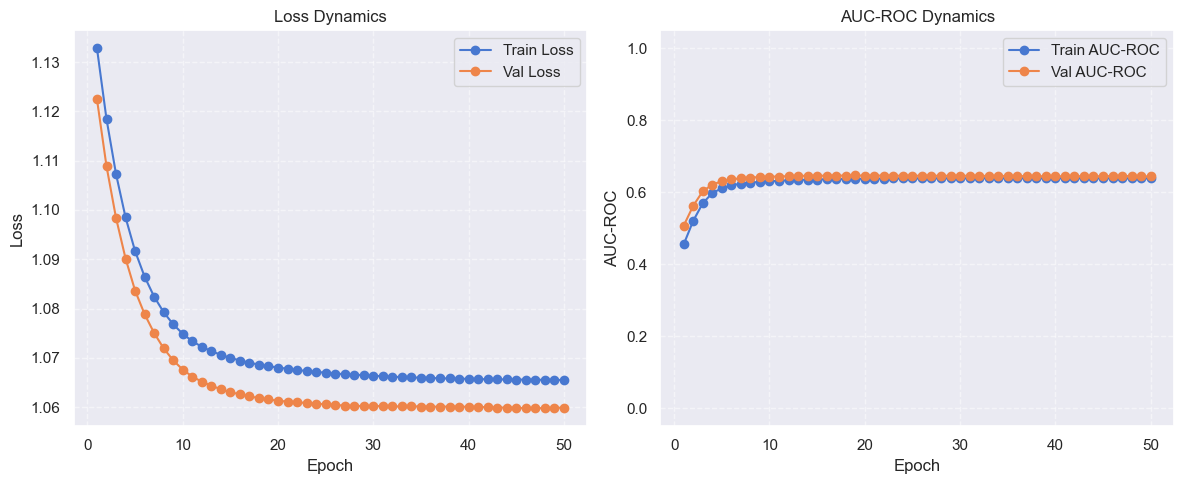

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train/loss,█▇▅▄▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/roc_auc,▁▃▅▇▇███████████████████████████████████
val/loss,█▆▅▄▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/roc_auc,▁▄▆▇▇███████████████████████████████████
epoch,50
train/loss,1.0655
train/roc_auc,0.63865
val/loss,1.05991
val/roc_auc,0.64402


In [20]:
history = fit(model, train_loader, val_loader, optimizer, criterion, torch.device('cpu'), 50, plot_fn=plot_metrics, use_wandb=True, wandb_project='gp5_tabular_model1', wandb_run_name='run0' ,out_dir='model1', save_every_n_epochs=5)

In [22]:
validation_epoch(model, criterion, test_loader, torch.device('cpu'))

Valid: 100%|██████████| 8/8 [00:00<00:00, 230.78it/s, loss=1.0447]


{'loss': 1.0446874775715085, 'roc_auc': 0.59319315967157}

### Попробуем модель побольше

In [24]:
wandb_config = {
    "project": "gp5_tabular_model2",
    "run_type": "train",
    "seed": 33,

    "dataset": "ISIC",
    "split": {
        "type": "stratified",
        "val_size": 0.1,
        "random_state": 33,
    },

    "device": "mps",
    "epochs": 50,
    "batch_size": 128,

    "optimizer": {
        "name": "Adam",
        "lr": 0.0005,
        "betas": [0.9, 0.999],
        "eps": 1e-8,
    },
    "criterion": "BCEWithLogitsLoss",

    "log": {
        "log_every_epoch": True,
        "save_best": True,
        "checkpoint_dir": "model2",
    }
}

In [25]:
model = nn.Sequential(
    nn.Linear(10, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 1)
)

train_dataset = data.TensorDataset(torch.tensor(train_data.drop(columns='target').to_numpy().astype(float)), torch.tensor(train_data['target'].to_numpy().astype(float)))
val_dataset = data.TensorDataset(torch.tensor(val_data.drop(columns='target').to_numpy().astype(float)), torch.tensor(val_data['target'].to_numpy().astype(float)))
test_dataset = data.TensorDataset(torch.tensor(test.drop(columns='target').to_numpy().astype(float)), torch.tensor(test['target'].to_numpy().astype(float)))

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor((train_data['target'] == 0).sum() / (train_data['target'] == 1).sum()))

train_loader = data.DataLoader(train_dataset, 128, shuffle=True)
val_loader = data.DataLoader(val_dataset, 1024)
test_loader = data.DataLoader(test_dataset, 1024)

optimizer = torch.optim.Adam(model.parameters(), 0.0005)

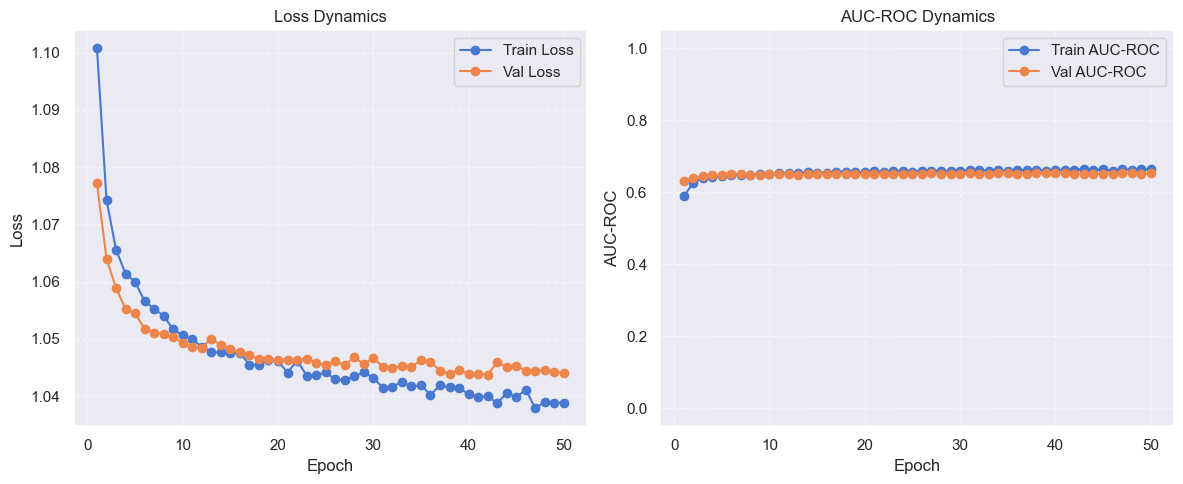

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train/loss,█▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁
train/roc_auc,▁▄▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇████▇████████████████
val/loss,█▆▅▅▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▂▂▁▁▁▁▁▂▂▁▁▁▁
val/roc_auc,▁▄▅▆▆▇▇▆▇▇▇▇▇▇▇▇▇▇▇▇█▇▇▇█▇█▇▇▇███▇▇▇▇███
epoch,50
train/loss,1.03889
train/roc_auc,0.66375
val/loss,1.04415
val/roc_auc,0.65317


In [26]:
history = fit(model, train_loader, val_loader, optimizer, criterion, torch.device('cpu'), 50, plot_fn=plot_metrics, use_wandb=True, wandb_project='gp5_tabular_model2', wandb_run_name='run0' ,out_dir='model2', save_every_n_epochs=5)

In [27]:
validation_epoch(model, criterion, test_loader, torch.device('cpu'))

Valid: 100%|██████████| 8/8 [00:00<00:00, 65.48it/s, loss=1.0802]


{'loss': 1.0801969087770769, 'roc_auc': 0.5749981255720779}

### Добавим BN, поменяем активации

In [30]:
wandb_config = {
    "project": "gp5_tabular_model3",
    "run_type": "train",
    "seed": 33,

    "dataset": "ISIC",
    "split": {
        "type": "stratified",
        "val_size": 0.1,
        "random_state": 33,
    },

    "device": "mps",
    "epochs": 50,
    "batch_size": 128,

    "optimizer": {
        "name": "Adam",
        "lr": 0.0005,
        "betas": [0.9, 0.999],
        "eps": 1e-8,
    },
    "criterion": "BCEWithLogitsLoss",

    "log": {
        "log_every_epoch": True,
        "save_best": True,
        "checkpoint_dir": "model3",
    }
}

In [31]:
model = nn.Sequential(
    nn.Linear(10, 32),
    nn.GELU(),
    nn.Linear(32, 32),
    nn.BatchNorm1d(32),
    nn.GELU(),
    nn.Linear(32, 64),
    nn.Dropout(0.3),
    nn.Linear(64, 1)
)

train_dataset = data.TensorDataset(torch.tensor(train_data.drop(columns='target').to_numpy().astype(float)), torch.tensor(train_data['target'].to_numpy().astype(float)))
val_dataset = data.TensorDataset(torch.tensor(val_data.drop(columns='target').to_numpy().astype(float)), torch.tensor(val_data['target'].to_numpy().astype(float)))
test_dataset = data.TensorDataset(torch.tensor(test.drop(columns='target').to_numpy().astype(float)), torch.tensor(test['target'].to_numpy().astype(float)))

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor((train_data['target'] == 0).sum() / (train_data['target'] == 1).sum()))

train_loader = data.DataLoader(train_dataset, 128, shuffle=True)
val_loader = data.DataLoader(val_dataset, 1024)
test_loader = data.DataLoader(test_dataset, 1024)

optimizer = torch.optim.Adam(model.parameters(), 0.0005)

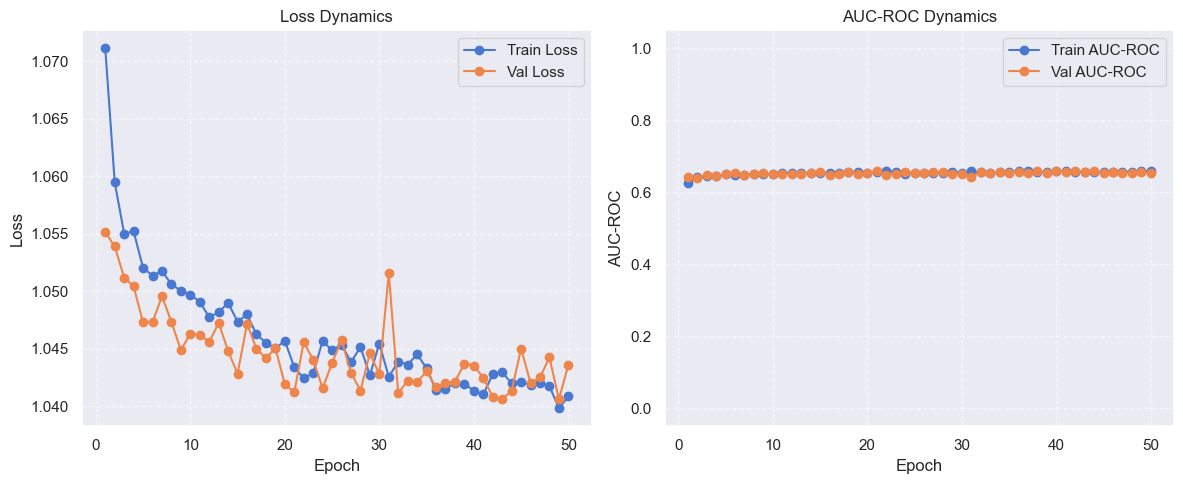

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇██
train/loss,█▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▁▁▂▂▂▂▁▂▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
train/roc_auc,▁▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇███▇▇▇▇▇██▇▇▇██▇███████
val/loss,█▆▆▄▄▄▃▄▄▃▃▂▄▃▃▂▁▃▃▁▃▂▁▃▂▁▂▂▂▂▂▂▂▁▁▃▂▂▃▂
val/roc_auc,▁▁▄▅▆▅▆▅▅▅▆▇▄▅▇▆█▄▅▇▇▇▅▅▂▆▇▆▇▆▆█▇█▇▅▇▆▆▆
epoch,50
train/loss,1.04084
train/roc_auc,0.65863
val/loss,1.04358
val/roc_auc,0.65344


In [32]:
history = fit(model, train_loader, val_loader, optimizer, criterion, torch.device('cpu'), 50, plot_fn=plot_metrics, use_wandb=True, wandb_project='gp5_tabular_model3', wandb_run_name='run0' ,out_dir='model3', save_every_n_epochs=5)